# Сверточные нейронные сети

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms.v2 as T
from IPython.display import clear_output
from PIL import Image
from matplotlib import cm
from time import perf_counter
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import os

warnings.filterwarnings('ignore')

# plt.rc('font', size=30)

## Загрузка изображения

Загрузим изображение из интернета, например, Питер Гриффина из одноименного мультсериала "Гриффины".

In [2]:
!wget "https://static.independent.co.uk/2021/10/29/14/newFile-8.jpg?width=1200" -O peter.jpg

--2025-11-03 14:44:49--  https://static.independent.co.uk/2021/10/29/14/newFile-8.jpg?width=1200
Resolving static.independent.co.uk (static.independent.co.uk)... 2a04:4e42:8e::347
Connecting to static.independent.co.uk (static.independent.co.uk)|2a04:4e42:8e::347|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 112326 (110K) [image/jpeg]
Saving to: ‘peter.jpg’

peter.jpg           100%[===================>] 109.69K  --.-KB/s    in 0.08s   

2025-11-03 14:44:49 (1.40 MB/s) - ‘peter.jpg’ saved [112326/112326]



## Чтение изображения

In [3]:
img = Image.open('peter.jpg')

In [5]:
img.format

'JPEG'

In [6]:
img.size

(1200, 899)

In [7]:
img.mode

'RGB'

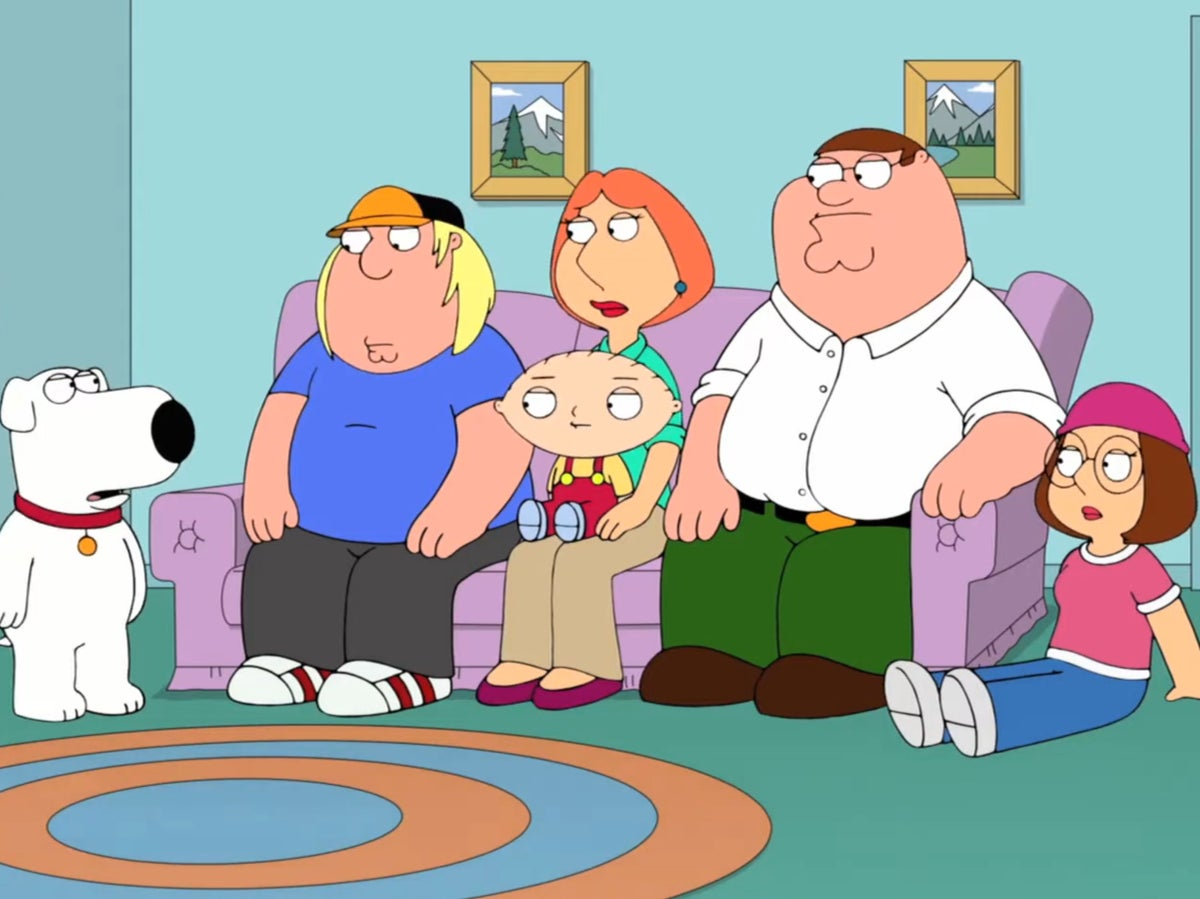

In [4]:
img

## Матричное представление

In [8]:
img_matrix = T.ToTensor()(img)

In [9]:
img_matrix.shape

torch.Size([3, 899, 1200])

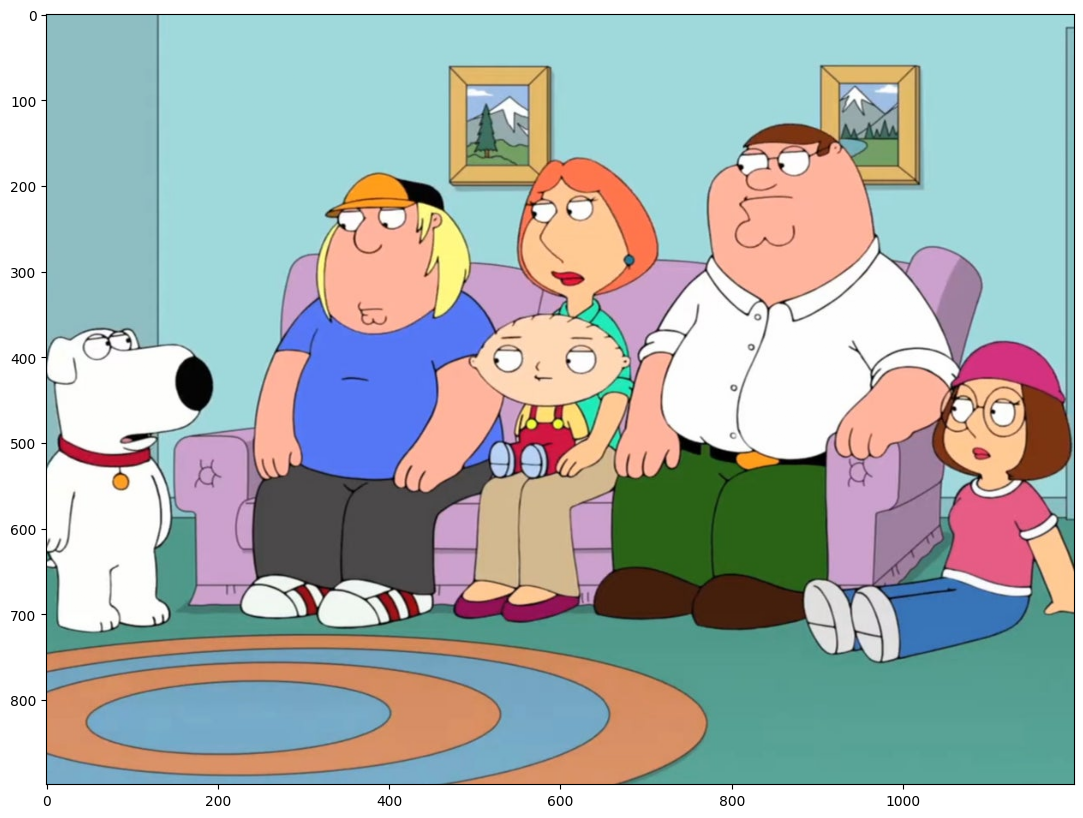

In [11]:
plt.figure(figsize=(20, 10))
plt.imshow(img_matrix.permute(1, 2, 0))
plt.show()

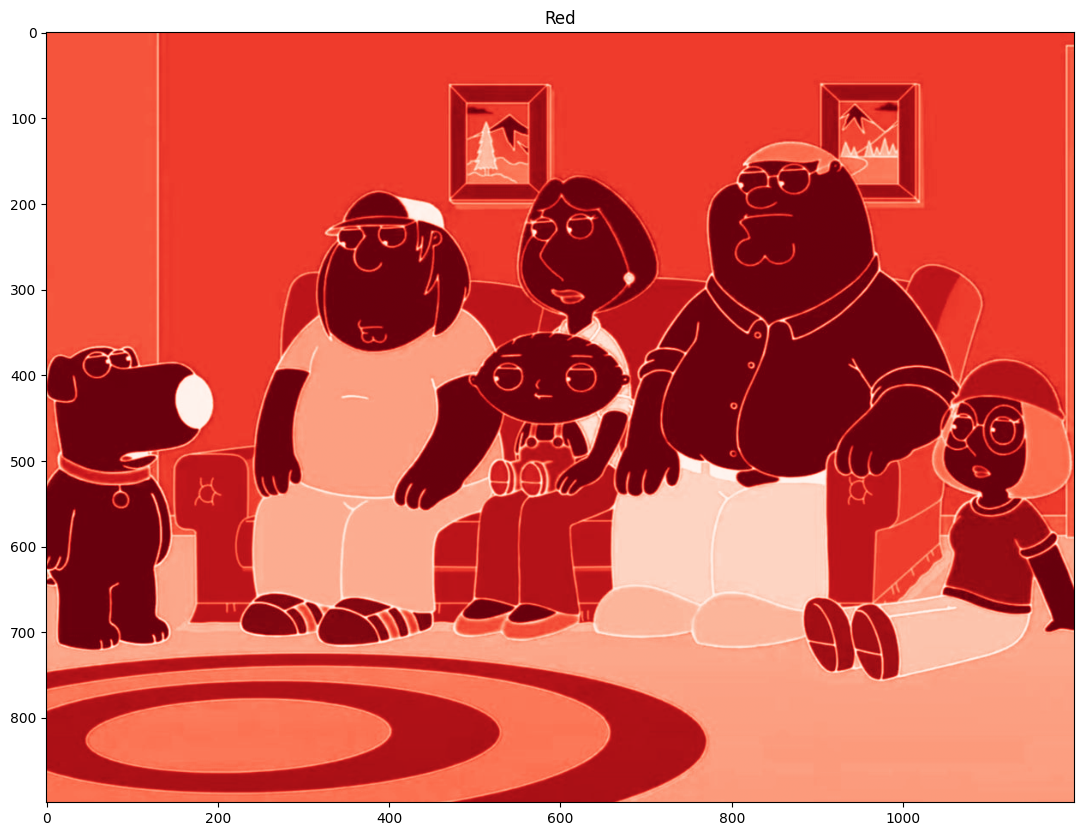

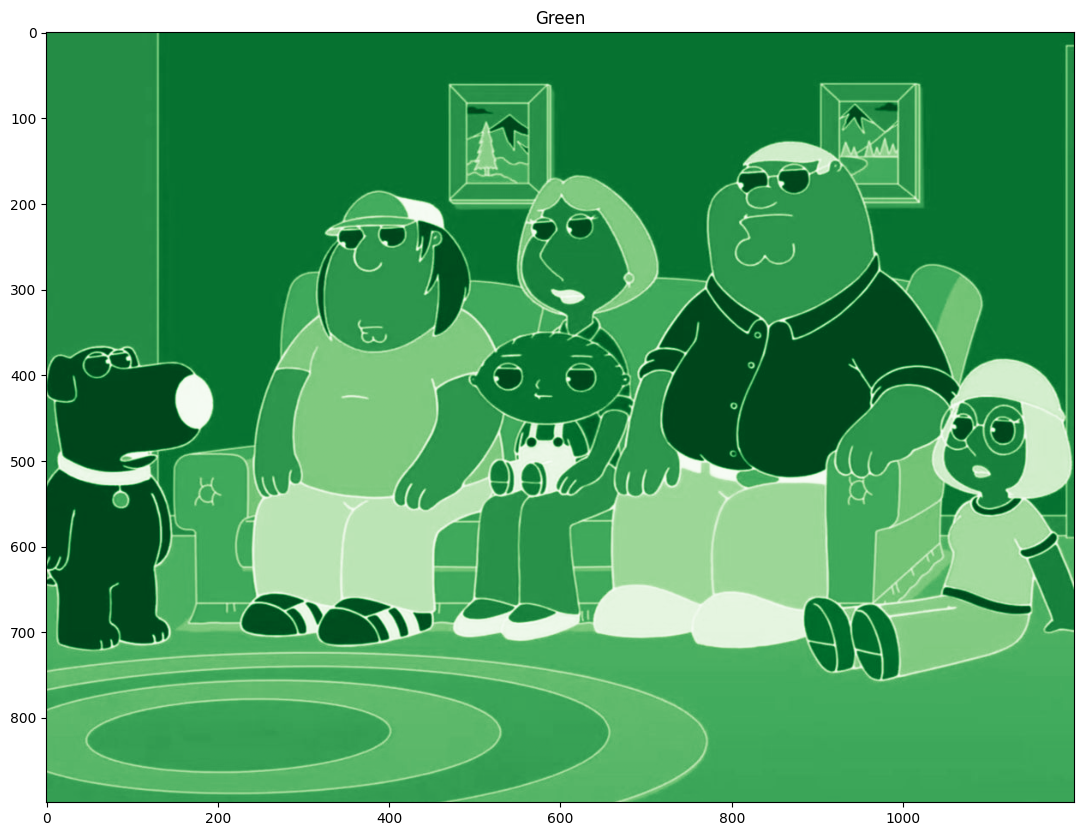

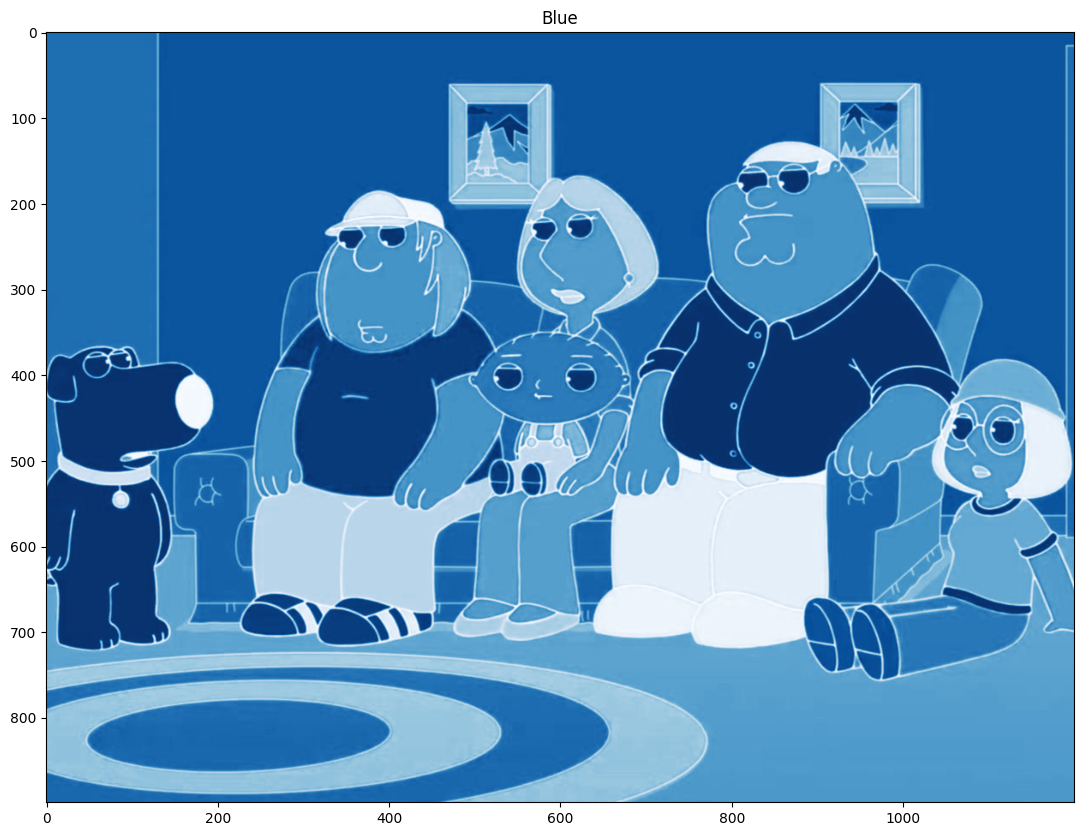

In [12]:
for i, (cmap, color) in enumerate(
    zip(
        [cm.Reds, cm.Greens, cm.Blues],
        ['Red', 'Green', 'Blue']
    )
):
    plt.figure(figsize=(20, 10))
    plt.imshow(img_matrix[i], cmap=cmap)
    plt.title(color)
    plt.show()

In [13]:
img_matrix.min(), img_matrix.max()

(tensor(0.), tensor(1.))

In [14]:
img_matrix

tensor([[[0.5569, 0.5569, 0.5569,  ..., 0.6157, 0.6157, 0.6157],
         [0.5569, 0.5569, 0.5569,  ..., 0.6157, 0.6157, 0.6157],
         [0.5569, 0.5569, 0.5569,  ..., 0.6196, 0.6196, 0.6196],
         ...,
         [0.4745, 0.4745, 0.4745,  ..., 0.3569, 0.3569, 0.3569],
         [0.4745, 0.4745, 0.4745,  ..., 0.3569, 0.3569, 0.3569],
         [0.4745, 0.4745, 0.4745,  ..., 0.3569, 0.3569, 0.3569]],

        [[0.7451, 0.7451, 0.7451,  ..., 0.8549, 0.8549, 0.8549],
         [0.7451, 0.7451, 0.7451,  ..., 0.8549, 0.8549, 0.8549],
         [0.7451, 0.7451, 0.7451,  ..., 0.8549, 0.8549, 0.8549],
         ...,
         [0.6745, 0.6745, 0.6745,  ..., 0.6471, 0.6471, 0.6471],
         [0.6745, 0.6745, 0.6745,  ..., 0.6471, 0.6471, 0.6471],
         [0.6745, 0.6745, 0.6745,  ..., 0.6471, 0.6471, 0.6471]],

        [[0.7608, 0.7608, 0.7608,  ..., 0.8588, 0.8588, 0.8588],
         [0.7608, 0.7608, 0.7608,  ..., 0.8588, 0.8588, 0.8588],
         [0.7608, 0.7608, 0.7608,  ..., 0.8588, 0.8588, 0.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4236407..1.429554].


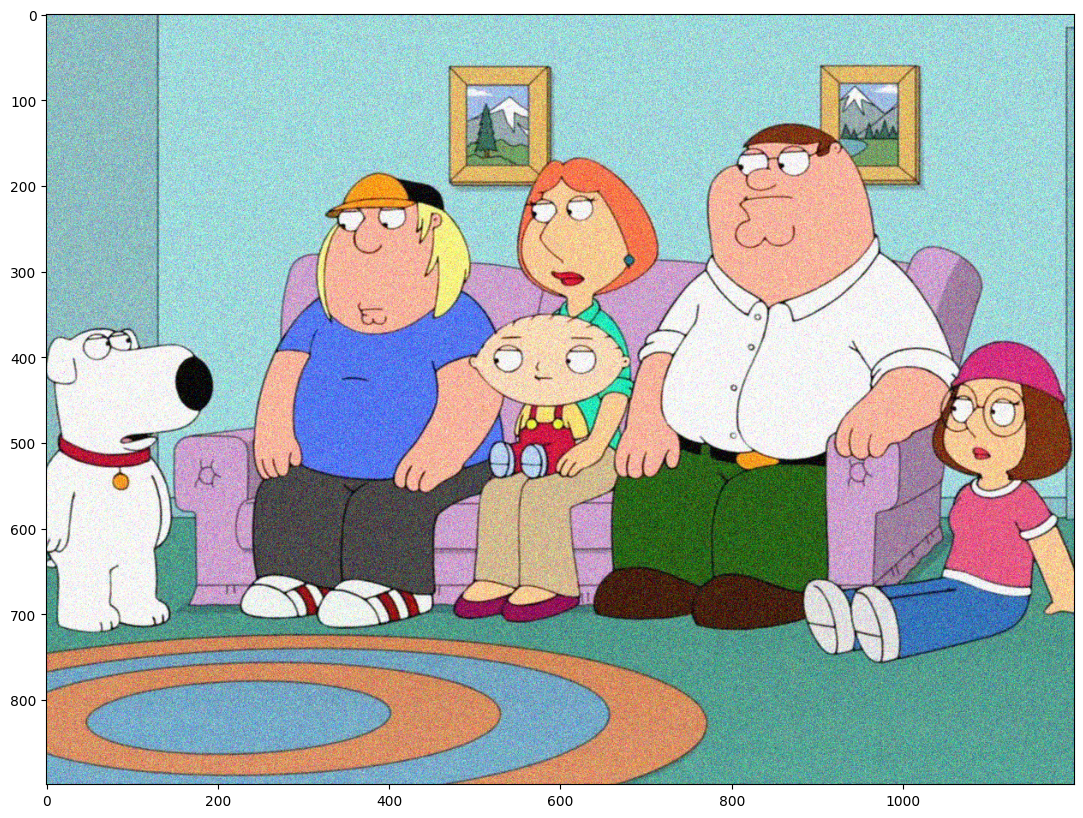

In [15]:
noise_photo = img_matrix + torch.randn_like(img_matrix) * 0.1

plt.figure(figsize=(20, 10))
plt.imshow(noise_photo.permute(1, 2, 0))
plt.show()

## Свертка

Свертка в `PyTorch` представлена модулем `nn.Conv2d` со следующими параметрами:

- in_channels (int) – Количество каналов во входном изображении

- out_channels (int) – Количество каналов в выходном изображении

- kernel_size (int or tuple) – Размер ядра свертки

- stride (int or tuple, optional) – Страйд (шаг ядра свертки). По умолчанию: 1

- padding (int, tuple or str, optional) – Размер паддинга. По умолчанию: 0

- padding_mode (string, optional) – 'zeros', 'reflect', 'replicate' or 'circular'. По умолчанию: 'zeros'

- dilation (int or tuple, optional) – Дилейшн (шаг между элементами внутри ядра). По умолчанию: 1

- bias (bool, optional) – добавлять ли обучаемый сдвиг. По умолчанию: True

https://github.com/vdumoulin/conv_arithmetic

In [16]:
conv1 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3
    # stride = 1
    # padding = 0
    # dilation = 1
    # groups = 1
)

In [17]:
(1200 + 2 * 0 - 1 * 2 - 1) / 1 + 1

1198.0

$\begin{aligned} & H_{\text {out }}=\left\lfloor\frac{H_{\text {in }}+2 \times \text { padding }[0]-\operatorname{dilation}[0] \times(\text { kernel size }[0]-1)-1}{\text { stride }[0]}+1\right\rfloor \\ & W_{\text {out }}=\left\lfloor\frac{W_{\text {in }}+2 \times \text { padding }[1]-\operatorname{dilation}[1] \times(\text { kernel size }[1]-1)-1}{\operatorname{stride}[1]}+1\right\rfloor\end{aligned}$

In [18]:
img_tensor = img_matrix.unsqueeze(0)

In [19]:
img_tensor.shape

torch.Size([1, 3, 899, 1200])

In [20]:
output = conv1(img_tensor)

In [21]:
output.shape

torch.Size([1, 10, 897, 1198])

In [22]:
conv2 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3,
    padding=1
)

In [23]:
output = conv2(img_tensor)

In [24]:
output.shape

torch.Size([1, 10, 899, 1200])

In [23]:
conv2.weight

Parameter containing:
tensor([[[[-0.0085, -0.1685, -0.0570],
          [-0.1447,  0.1383,  0.1125],
          [ 0.0909, -0.1281, -0.1019]],

         [[ 0.1088, -0.1166, -0.0715],
          [-0.0053,  0.1923, -0.1917],
          [-0.0511, -0.1670,  0.0254]],

         [[-0.0967,  0.1380, -0.1725],
          [ 0.0583, -0.0618, -0.1172],
          [-0.0638, -0.0224, -0.1379]]],


        [[[-0.0903, -0.0034, -0.1238],
          [-0.0114,  0.1340,  0.0875],
          [-0.0949, -0.0989, -0.1682]],

         [[ 0.0303, -0.0398, -0.1396],
          [-0.1037, -0.1919,  0.1590],
          [-0.1584, -0.1032,  0.1002]],

         [[-0.0041,  0.1518,  0.1878],
          [ 0.1792,  0.0051,  0.0840],
          [-0.1825,  0.1579, -0.1355]]],


        [[[-0.1674,  0.0244,  0.1487],
          [-0.1326, -0.1267,  0.1073],
          [ 0.0668,  0.0602,  0.0869]],

         [[-0.1698, -0.1423,  0.0661],
          [-0.0247, -0.1406,  0.1478],
          [ 0.0997, -0.1612,  0.1604]],

         [[-0.1501,  0

In [25]:
conv2.weight.shape

torch.Size([10, 3, 3, 3])

In [26]:
conv2.bias.shape

torch.Size([10])

### im2col vs conv2d

In [31]:
x = torch.arange(1, 25, dtype=torch.float32).reshape(2, 1, 3, 4)

conv = torch.nn.Conv2d(1, 6, 3, bias=False)

In [32]:
x

tensor([[[[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.]]],


        [[[13., 14., 15., 16.],
          [17., 18., 19., 20.],
          [21., 22., 23., 24.]]]])

In [33]:
import torch.nn.functional as F

x_unfold = F.unfold(x, kernel_size=(3, 3), stride=1)  # (2, 9, 2)

In [34]:
x_unfold

tensor([[[ 1.,  2.],
         [ 2.,  3.],
         [ 3.,  4.],
         [ 5.,  6.],
         [ 6.,  7.],
         [ 7.,  8.],
         [ 9., 10.],
         [10., 11.],
         [11., 12.]],

        [[13., 14.],
         [14., 15.],
         [15., 16.],
         [17., 18.],
         [18., 19.],
         [19., 20.],
         [21., 22.],
         [22., 23.],
         [23., 24.]]])

In [35]:
y = torch.matmul(conv.weight.data.view(-1, 9), x_unfold).view(2, 6, 1, 2)

In [36]:
y

tensor([[[[ -4.4738,  -5.0288]],

         [[  0.0256,   0.1020]],

         [[  5.3825,   5.6503]],

         [[ -1.8880,  -1.8902]],

         [[ -1.2533,  -0.9761]],

         [[ -4.2567,  -4.8082]]],


        [[[-11.1339, -11.6889]],

         [[  0.9421,   1.0185]],

         [[  8.5964,   8.8642]],

         [[ -1.9145,  -1.9167]],

         [[  2.0729,   2.3501]],

         [[-10.8743, -11.4258]]]])

In [37]:
y2 = conv(x)
y2

tensor([[[[ -4.4738,  -5.0288]],

         [[  0.0256,   0.1020]],

         [[  5.3825,   5.6503]],

         [[ -1.8880,  -1.8902]],

         [[ -1.2533,  -0.9761]],

         [[ -4.2567,  -4.8082]]],


        [[[-11.1339, -11.6889]],

         [[  0.9421,   1.0185]],

         [[  8.5964,   8.8642]],

         [[ -1.9145,  -1.9167]],

         [[  2.0729,   2.3501]],

         [[-10.8743, -11.4258]]]], grad_fn=<ConvolutionBackward0>)

### fft vs conv2d

In [145]:
x

tensor([[[[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.]]],


        [[[13., 14., 15., 16.],
          [17., 18., 19., 20.],
          [21., 22., 23., 24.]]]])

In [38]:
w_shape = conv.weight.data.shape

In [39]:
x_pad = torch.zeros(x.shape[0], x.shape[1], x.shape[2] + w_shape[2] - 1, x.shape[3] + w_shape[3] - 1, dtype=x.dtype)
x_pad[:, :, :x.shape[2], :x.shape[3]] = x

w_flipped = conv.weight.data.flip(-1).flip(-2)
w_pad = torch.zeros(w_shape[0], w_shape[1], x.shape[2] + w_shape[2] - 1, x.shape[3] + w_shape[3] - 1, dtype=x.dtype)
w_pad[:, :, :w_shape[2], :w_shape[3]] = w_flipped

In [40]:
from torch.fft import fft2, ifft2

X_fft = fft2(x_pad)
W_fft = fft2(w_pad)

In [41]:
X_fft_ = X_fft[:, None]      # (B, 1, C_in, fft_h, fft_w)
W_fft_ = W_fft[None, :]      # (1, C_out, C_in, fft_h, fft_w)

out_fft = (X_fft_ * W_fft_).sum(dim=2)  # (B, C_out, fft_h, fft_w)

In [43]:
out_full = ifft2(out_fft).real
out = out_full[:, :, w_shape[2] - 1: w_shape[2] - 1 + x.shape[2] - w_shape[2] + 1, w_shape[3] - 1: w_shape[3] - 1 + x.shape[3] - w_shape[3] + 1]

In [44]:
out

tensor([[[[ -4.4738,  -5.0288]],

         [[  0.0256,   0.1020]],

         [[  5.3825,   5.6503]],

         [[ -1.8880,  -1.8902]],

         [[ -1.2533,  -0.9761]],

         [[ -4.2567,  -4.8082]]],


        [[[-11.1339, -11.6889]],

         [[  0.9421,   1.0185]],

         [[  8.5964,   8.8642]],

         [[ -1.9145,  -1.9167]],

         [[  2.0729,   2.3501]],

         [[-10.8743, -11.4258]]]])

In [45]:
torch.allclose(y, y2, atol=1e-4), torch.allclose(out, y2, atol=1e-4)

(True, True)

## Пулинг

Пулинг представлен в модуле `torch.nn`, в основном будем использовать `MaxPool2d` и `AvgPool2d`.

Параметры:

- kernel_size – размер окошка

- stride – страйд окошка. По умолчанию равен kernel_size

- padding – сколько нулевого паддинга добавлять по краям. По умолчанию: 0.

In [46]:
img_tensor = torch.randint(0, 10, size=(10, 10), dtype=torch.float32).unsqueeze(0)

In [47]:
img_tensor

tensor([[[3., 1., 9., 8., 8., 9., 7., 5., 4., 1.],
         [7., 5., 9., 3., 6., 2., 9., 0., 6., 5.],
         [3., 7., 4., 4., 1., 7., 3., 2., 2., 7.],
         [8., 6., 0., 8., 4., 4., 0., 7., 1., 5.],
         [4., 7., 4., 5., 7., 4., 0., 7., 0., 7.],
         [0., 3., 8., 6., 2., 7., 4., 2., 6., 5.],
         [3., 8., 2., 3., 1., 4., 5., 6., 2., 4.],
         [1., 7., 9., 9., 0., 7., 2., 9., 6., 4.],
         [0., 4., 5., 3., 5., 6., 1., 6., 3., 7.],
         [4., 1., 8., 4., 4., 4., 9., 7., 8., 7.]]])

In [48]:
pooling1 = nn.MaxPool2d(kernel_size=2)

In [49]:
pooling1(img_tensor)

tensor([[[7., 9., 9., 9., 6.],
         [8., 8., 7., 7., 7.],
         [7., 8., 7., 7., 7.],
         [8., 9., 7., 9., 6.],
         [4., 8., 6., 9., 8.]]])

In [50]:
pooling2 = nn.AvgPool2d(kernel_size=2)

In [51]:
pooling2(img_tensor)

tensor([[[4.0000, 7.2500, 6.2500, 5.2500, 4.0000],
         [6.0000, 4.0000, 4.0000, 3.0000, 3.7500],
         [3.5000, 5.7500, 5.0000, 3.2500, 4.5000],
         [4.7500, 5.7500, 3.0000, 5.5000, 4.0000],
         [2.2500, 5.0000, 4.7500, 5.7500, 6.2500]]])

## Подготовка данных

In [52]:
# !kaggle datasets download -d lantian773030/pokemonclassification
# !unzip -qq archive.zip

In [53]:
# !ls -la PokemonData/ | head

In [55]:
import glob

bad_images = glob.glob("PokemonData/*/*.svg")

In [56]:
import os
for bad_image in bad_images:
    os.remove(bad_image)

In [57]:
class PokemonDataset(Dataset):
    SPLIT_RANDOM_SEED = 42
    TEST_SIZE = 0.25

    def __init__(self, root, train=True, load_to_ram=True, transform=None):
        super().__init__()
        self.root = root
        self.train = train
        self.load_to_ram = load_to_ram
        self.transform = transform
        self.to_tensor = T.ToTensor()
        self.all_files = []
        self.all_labels = []
        self.images = []

        self.classes = sorted(os.listdir(self.root))
        for i, class_name in tqdm(enumerate(self.classes), total=len(self.classes)):
            files = sorted(os.listdir(os.path.join(self.root, class_name)))
            train_files, test_files = train_test_split(files, random_state=self.SPLIT_RANDOM_SEED + i,
                                                       test_size=self.TEST_SIZE)
            if self.train:
                self.all_files += train_files
                self.all_labels += [i] * len(train_files)
                if self.load_to_ram:
                    self.images += self._load_images(train_files, i)

            else:
                self.all_files += test_files
                self.all_labels += [i] * len(test_files)
                if self.load_to_ram:
                    self.images += self._load_images(test_files, i)

    def _load_images(self, image_files, label):
        images = []
        for filename in image_files:
            image = Image.open(os.path.join(self.root, self.classes[label], filename)).convert('RGB')
            images += [image]

        return images

    def __len__(self):
        return len(self.all_files)

    def __getitem__(self, item):
        label = self.all_labels[item]
        if self.load_to_ram:
            image = self.images[item]
        else:
            filename = self.all_files[item]
            image = Image.open(os.path.join(self.root, self.classes[label], filename)).convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [58]:
train_dataset = PokemonDataset(root='PokemonData', train=True, load_to_ram=False)

100%|██████████| 150/150 [00:00<00:00, 2702.20it/s]


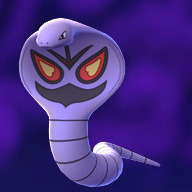

In [59]:
image, label = train_dataset[101]
image

In [60]:
train_dataset.classes[label]

'Arbok'

In [61]:
normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

test_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    normalize,
])

In [62]:
train_dataset = PokemonDataset(root='PokemonData', train=True, load_to_ram=True, transform=test_transform)
test_dataset = PokemonDataset(root='PokemonData', train=False, load_to_ram=True, transform=test_transform)

100%|██████████| 150/150 [00:04<00:00, 33.87it/s]


In [63]:
print(f'Число классов: {len(train_dataset.classes)}')

Число классов: 150


In [64]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True, num_workers=2)

In [65]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.notebook import tqdm


sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 15})


def plot_losses(train_losses, test_losses, train_accuracies, test_accuracies):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label='test')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_accuracies) + 1), train_accuracies, label='train')
    axs[1].plot(range(1, len(test_accuracies) + 1), test_accuracies, label='test')
    axs[1].set_ylabel('accuracy')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [67]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    train_loss, train_accuracy = 0.0, 0.0
    model.train()
    for images, labels in tqdm(train_loader, desc=tqdm_desc):
        images = images.to(device)  # images: batch_size x num_channels x height x width
        labels = labels.to(device)  # labels: batch_size

        optimizer.zero_grad()
        logits = model(images)  # logits: batch_size x num_classes
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.shape[0]
        train_accuracy += (logits.argmax(dim=1) == labels).sum().item()

    train_loss /= len(train_loader.dataset)
    train_accuracy /= len(train_loader.dataset)
    return train_loss, train_accuracy


@torch.no_grad()
def validation_epoch(model, criterion, test_loader, tqdm_desc):
    test_loss, test_accuracy = 0.0, 0.0
    model.eval()
    for images, labels in tqdm(test_loader, desc=tqdm_desc):
        images = images.to(device)  # images: batch_size x num_channels x height x width
        labels = labels.to(device)  # labels: batch_size
        logits = model(images)  # logits: batch_size x num_classes
        loss = criterion(logits, labels)

        test_loss += loss.item() * images.shape[0]
        test_accuracy += (logits.argmax(dim=1) == labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy /= len(test_loader.dataset)
    return test_loss, test_accuracy


def train(model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs):
    train_losses, train_accuracies = [], []
    test_losses, test_accuracies = [], []

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        test_loss, test_accuracy = validation_epoch(
            model, criterion, test_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        if scheduler is not None:
            scheduler.step()

        train_losses += [train_loss]
        train_accuracies += [train_accuracy]
        test_losses += [test_loss]
        test_accuracies += [test_accuracy]
        plot_losses(train_losses, test_losses, train_accuracies, test_accuracies)

    return train_losses, test_losses, train_accuracies, test_accuracies

## Простая модель

In [68]:
import torch.nn as nn
import torch.nn.functional as F

class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.pool = nn.AvgPool2d(kernel_size=28)
        self.linear = nn.Linear(2048, len(train_dataset.classes))

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))

        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.linear(x)

        return x

In [69]:
model = ConvNet().to(device)
num_epochs = 10
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

In [70]:
sum(param.numel() for param in model.parameters())

312534

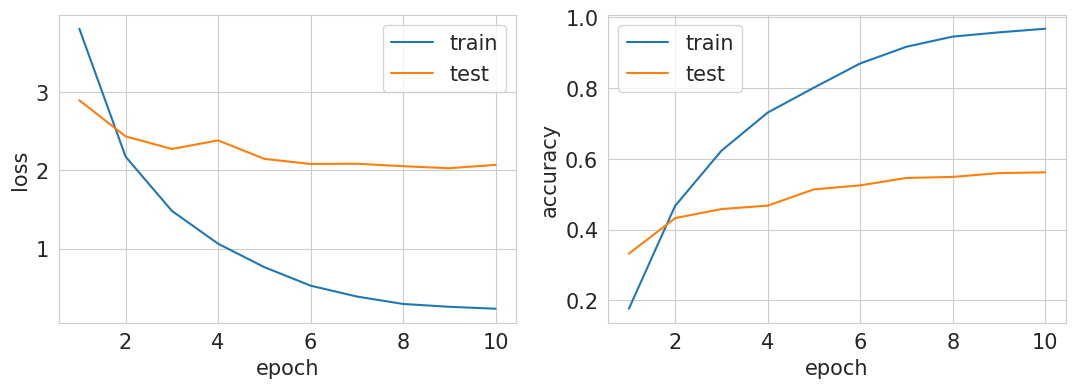

In [71]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [72]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.5618615209988649


## Готовая архитектура

In [73]:
from torchvision.models import resnet18

num_epochs = 10
model = resnet18(num_classes=len(train_dataset.classes)).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

In [74]:
sum(param.numel() for param in model.parameters())

11253462

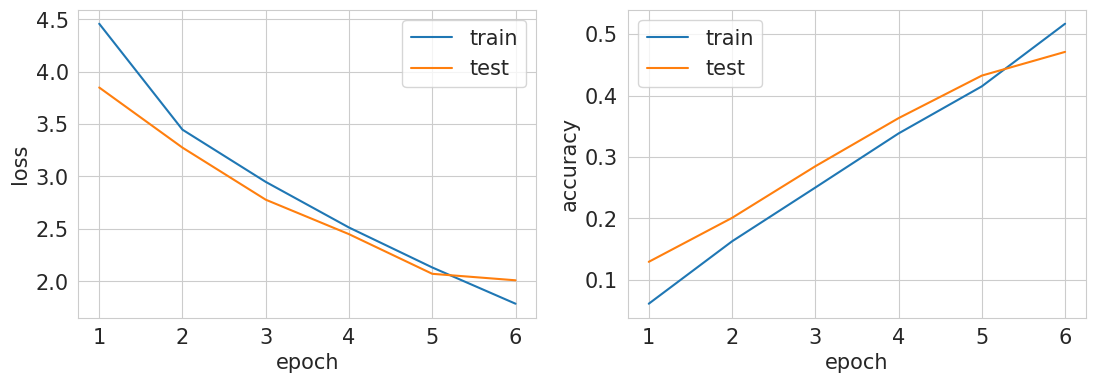

Training 7/10:   0%|          | 0/159 [00:00<?, ?it/s]

Exception ignored in: <function _releaseLock at 0x7fdceb5f8040>
Traceback (most recent call last):
  File "/home/free001style/miniconda3/envs/wan/lib/python3.12/logging/__init__.py", line 243, in _releaseLock
    def _releaseLock():
    
KeyboardInterrupt: 


RuntimeError: DataLoader worker (pid(s) 1773202) exited unexpectedly

In [75]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [55]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.6316685584562997


## Добавляем аугментации

In [76]:
train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    normalize,
])

In [77]:
train_dataset.transform = train_transform
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True, num_workers=2)

In [78]:
model = resnet18(num_classes=len(train_dataset.classes)).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

In [79]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

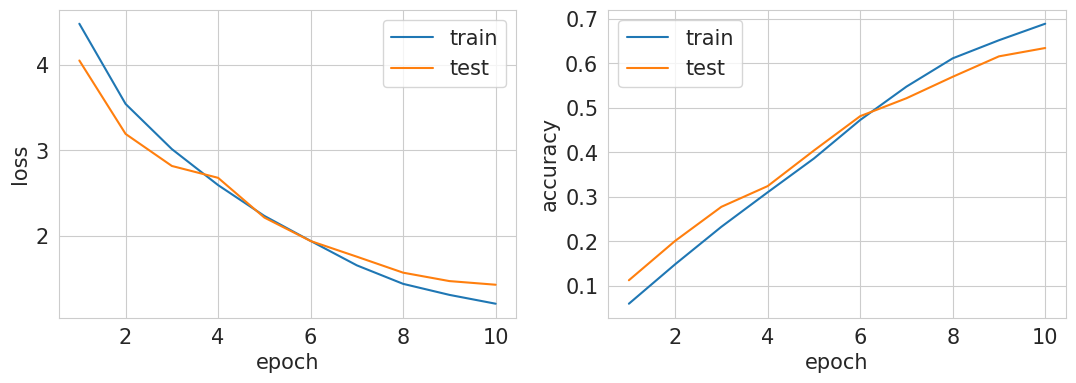

In [80]:
num_epochs = 10
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [81]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.6345062429057888


## Finetune

In [82]:
model = resnet18(pretrained=True).to(device)
model.fc = torch.nn.Linear(512, len(train_dataset.classes))
model = model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

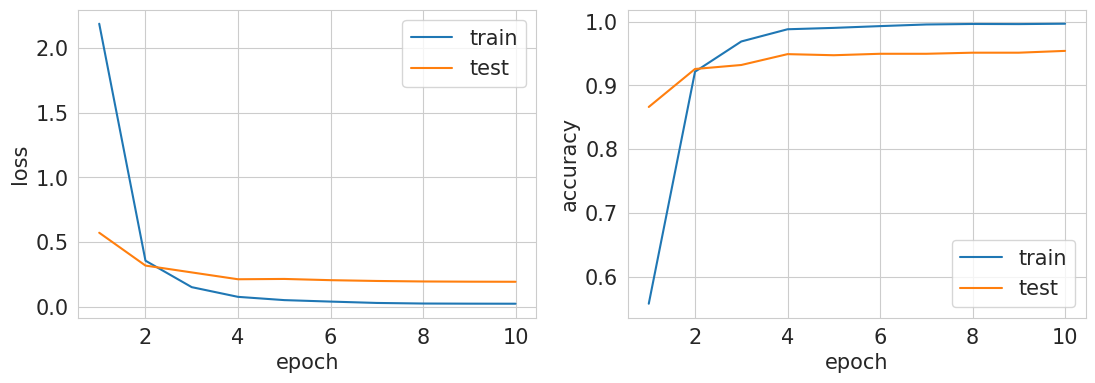

In [83]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [84]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.9540295119182747


## Linear Probing

In [85]:
model = resnet18(pretrained=True).to(device)
model.fc = torch.nn.Linear(512, len(train_dataset.classes))
model = model.to(device)

for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.SGD([param for param in model.parameters() if param.requires_grad], lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

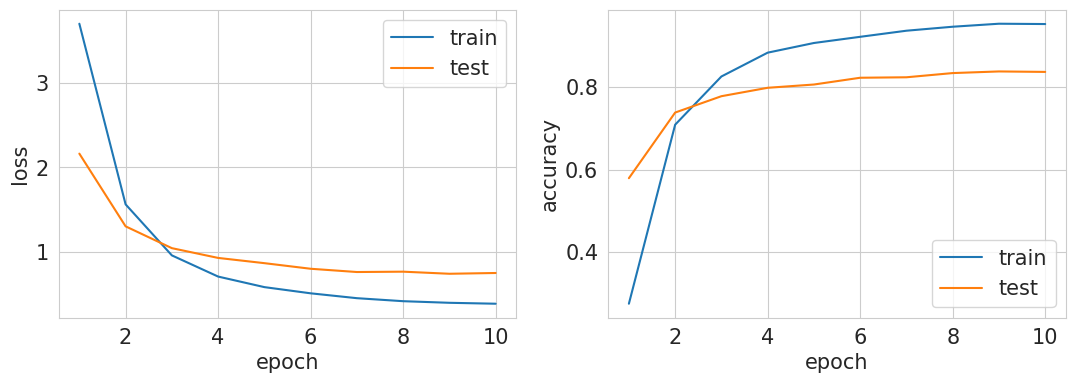

In [86]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [87]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.837116912599319
